## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 22.15it/s]


Numba compilation complete!
0.23.9


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251023"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
        


## Formulas to run


In [5]:
fallingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx")
MBONList = list(fallingexcel['MBON'].unique())

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Heatmap for specific MBONs comparing PI and so forth

In [6]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


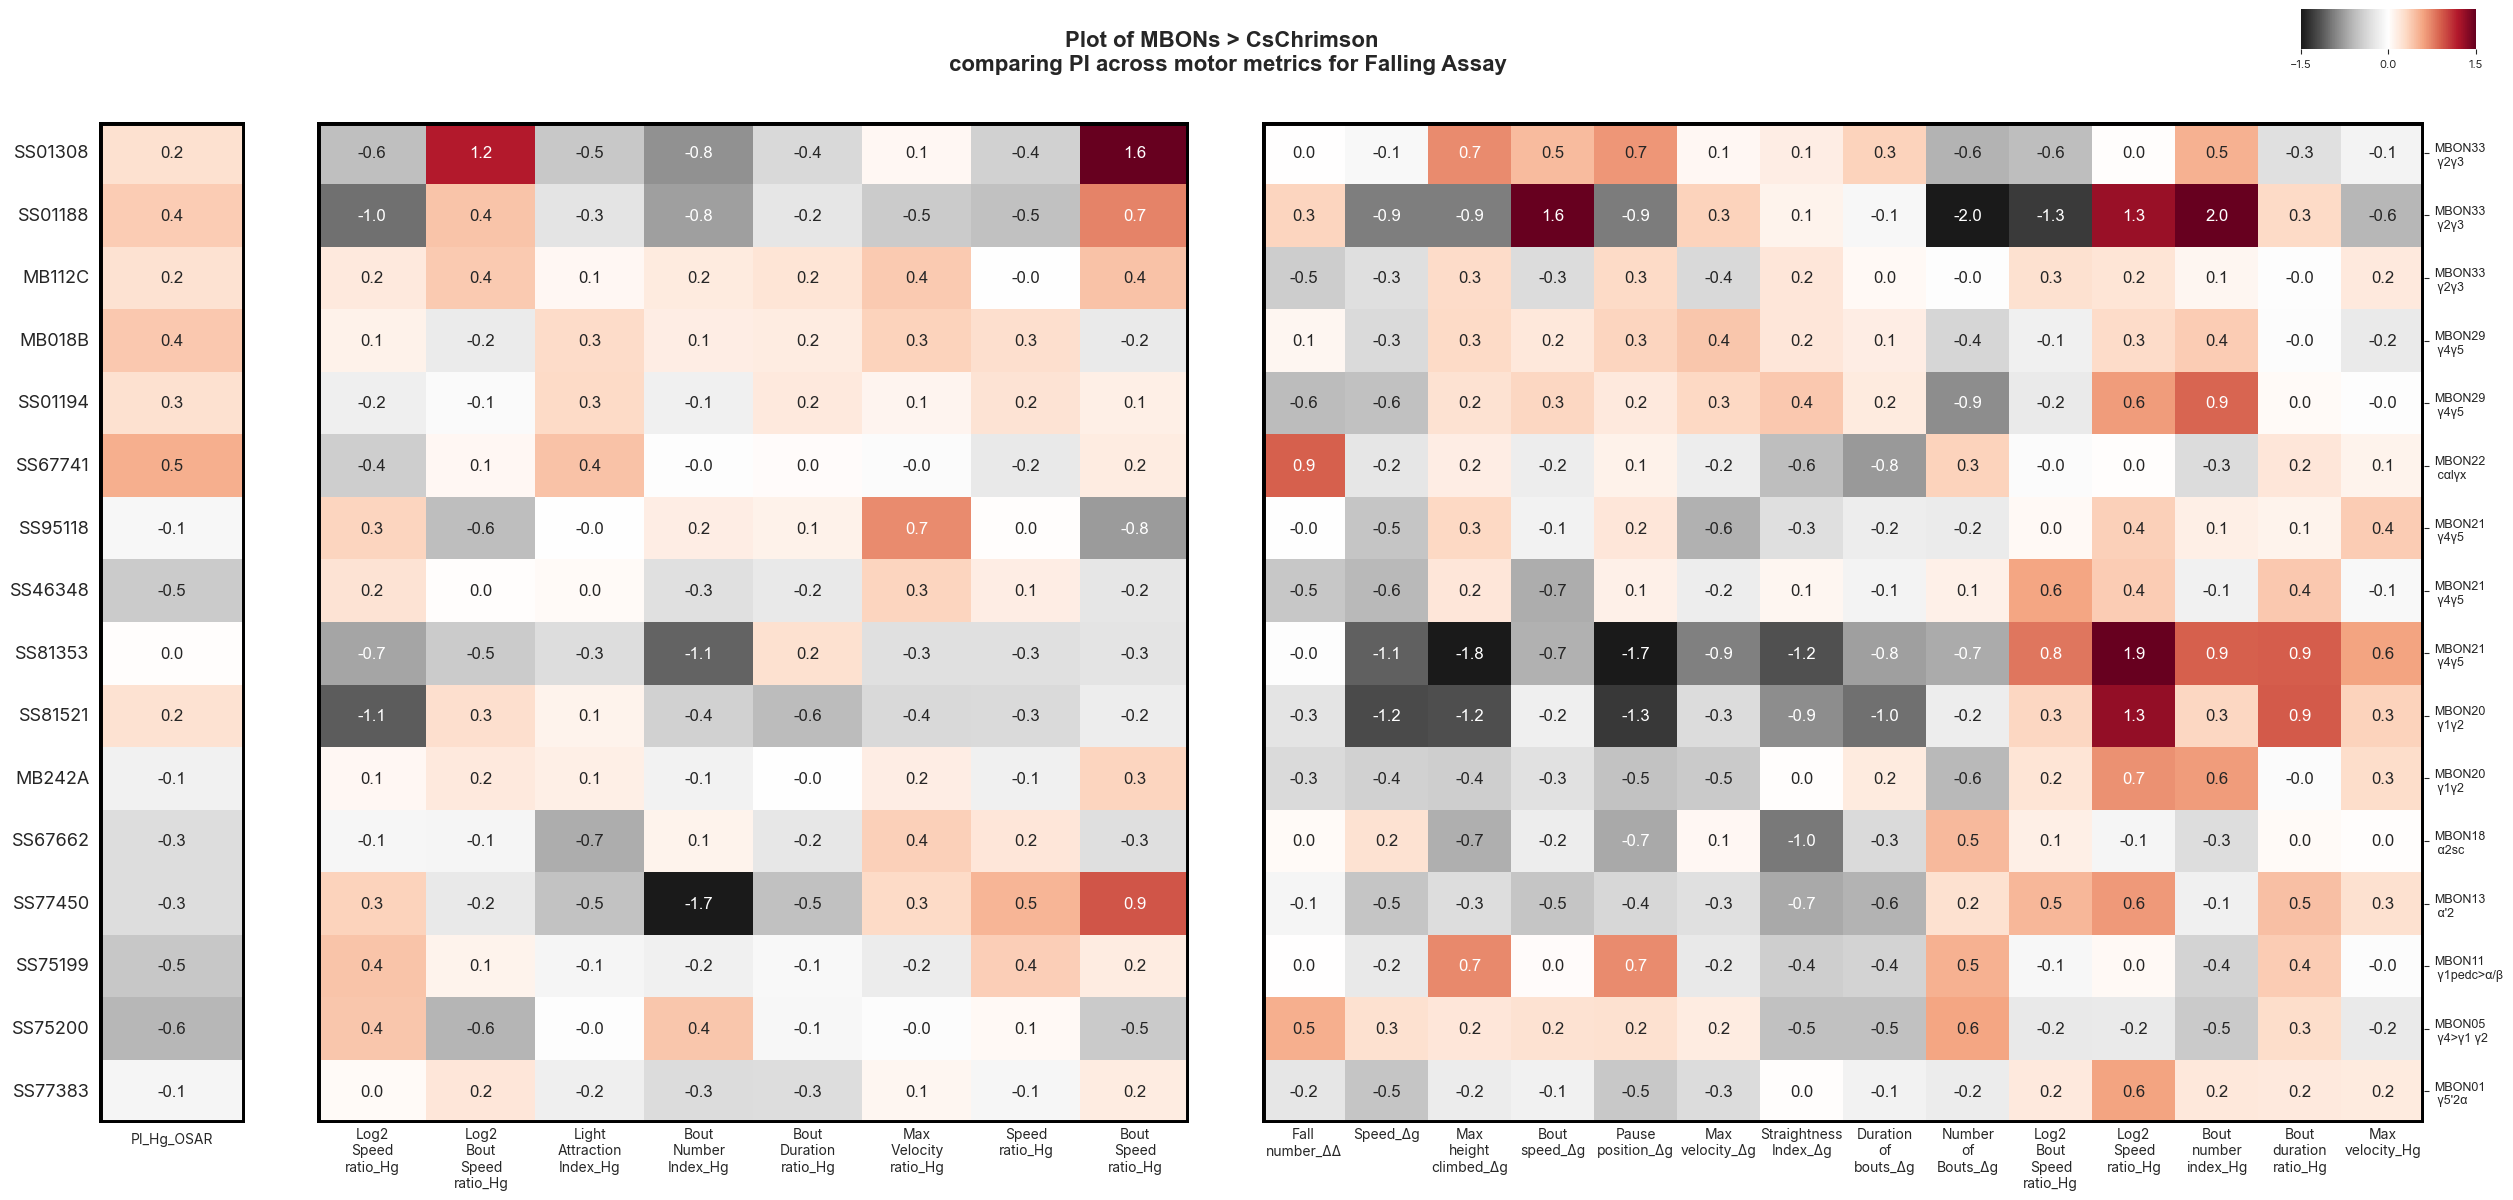

In [68]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"


# Read the specific condition file
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'RdGy_r'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'BrBG'

totalmapplots = df_linereg.drop(columns = ['genotypeandresponder', 'responder'])
df_totalmetrics_origin = totalmapplots[totalmapplots['MBON'].isin(singlecellmbon)]

## if i want specific mbons else skip
# mbons_of_interest = ['MB018B']
# df_totalmetrics_origin = totalmapplots[totalmapplots['MBON'].isin(mbons_of_interest)]
# df_totalmetrics = df_totalmetrics_origin.set_index(['MBON'])

# df_totalmetrics_origin = totalmapplots.copy()
df_totalmetrics = df_totalmetrics_origin.set_index(['MBON'])

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_totalmetrics.copy()

for n in df_totalmetrics_origin['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True)

# Separate data for three subplots
# Subplot 1: Only PI data
df60_PIonly = df_singleresponder_lobeloc[['PI_Hg_OSAR']].copy()

# Subplot 2: for anything with _OSAR (excluding PI)
df60_osaronly = df_singleresponder_lobeloc.filter(regex='_OSAR$').drop(columns=['PI_Hg_OSAR']).copy()

# Subplot 3: for anything with _Falling 
df60_fallingonly = df_singleresponder_lobeloc.filter(regex='_Falling$').copy()

# Create figure with 3 subplots
fig1, (ax4_left, ax4_middle, ax4_right) = plt.subplots(1, 3, figsize=(30, 13), gridspec_kw={'width_ratios': [1, 6, 8], 'wspace': 0.1})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (PI only)
xticklabel_subplot1 = ['PI_Hg_OSAR']

# Labels for subplot 2 (OSAR only)
xticklabellist_osar = [a.replace("_OSAR", " ") for a in df60_osaronly.columns.tolist()]

# Labels for subplot 3 (Falling only)
xticklabellist_falling = [a.replace("_Falling", " ") for a in df60_fallingonly.columns.tolist()]

# Colorbar for subplot 3 (rightmost)
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="4%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.02, 1.1, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: PI only (left) - with MBON names as y-labels       
j7_left = sns.heatmap(df60_PIonly, ax=ax4_left, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                     annot_kws={"size": 12}, linewidths=0.0, edgecolor="none", 
                     xticklabels=xticklabel_subplot1, yticklabels=True, clip_on=False, cbar=False)

# Subplot 2: OSAR only (middle) - no y-labels
j7_middle = sns.heatmap(df60_osaronly, ax=ax4_middle, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                       annot_kws={"size": 12}, linewidths=0.0, edgecolor="none", 
                       xticklabels=xticklabellist_osar, yticklabels=False, clip_on=False, cbar=False)

# Subplot 3: Falling only (right) - no y-labels on left side, colorbar
j7_right = sns.heatmap(df60_fallingonly, ax=ax4_right, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                      linewidths=0.0, edgecolor="none", xticklabels=xticklabellist_falling, yticklabels=False,
                      clip_on=False, cbar_ax=cax2, cbar_kws=dict(orientation="horizontal", ticks=[-1.5, 0, 1.5]), 
                      annot_kws={"size": 12})

# Colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    label.set_family('Inter')

# Format subplot 1 (left - with j7_left y-labels)
j7_left.set_ylabel('')
j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation=0, fontsize=13)
j7_left.set_xticklabels(j7_left.get_xticklabels(), fontsize=10)

# Format subplot 2 (middle - no y-labels)
j7_middle.set_ylabel('')
j7_middle.set_xticklabels(j7_middle.get_xticklabels(), fontsize=10)
wrap_labels(j7_middle, 2)
j7_middle.tick_params(axis='both', which='both', length=0)

# Format subplot 3 (right)
j7_right.set_ylabel('')
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize=10)
wrap_labels(j7_right, 2)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing frames for all subplots
# Frame for subplot 1
j7_left.axhline(y=0, color='k', linewidth=5) 
j7_left.axhline(y=len(df60_PIonly), color='k', linewidth=5) 
j7_left.axvline(x=0, color='k', linewidth=5) 
j7_left.axvline(x=1, color='k', linewidth=5) 

# Frame for subplot 2
j7_middle.axhline(y=0, color='k', linewidth=5) 
j7_middle.axhline(y=len(df60_osaronly), color='k', linewidth=5) 
j7_middle.axvline(x=0, color='k', linewidth=5) 
j7_middle.axvline(x=len(df60_osaronly.columns), color='k', linewidth=5) 

# Frame for subplot 3
j7_right.axhline(y=0, color='k', linewidth=5) 
j7_right.axhline(y=len(df60_fallingonly), color='k', linewidth=5) 
j7_right.axvline(x=0, color='k', linewidth=5) 
j7_right.axvline(x=len(df60_fallingonly.columns), color='k', linewidth=5) 

# Secondary axes for subplot 3 - MBON lobe and naming labels on right side (j8_right)
j8_right = j7_right.twinx()
j8_right.set_ylim(j7_right.get_ylim())

# Y labels for MBON lobes and naming on subplot 3 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)

# Set ticks to match the data positions
tick_positions = [i + 0.5 for i in range(len(df60_fallingonly))]
j8_right.set_yticks(tick_positions)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Overall title
fig1.suptitle('Plot of MBONs > ' + responderrename +' \n comparing PI across motor metrics for Falling Assay', x=0.5, y=0.95, weight='bold', fontsize=16)
plt.rcParams["font.family"] = "Inter"
fig1.tight_layout()

# plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)
#plt.savefig(filesavedir + date + "_" + responder + "comparing PI against motor_hedgesgheatmap_2.svg")

In [79]:
metriccolumns = ['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Max height climbed_Δg_Falling', 'Bout speed_Δg_Falling',
       'Pause position_Δg_Falling', 'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 'MBON',
       
       'PI_Hg_OSAR', 'Log2 Speed ratio_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR']

fallingonly_cols = [n for n in metriccolumns if n.endswith('Falling')]
osaronly_cols = [n for n in metriccolumns if n.endswith('OSAR')]

df_nt_metricreduce = df_totalmetrics_origin[metriccolumns]
df_fallingcol = pd.concat([df_totalmetrics_origin[fallingonly_cols],df_totalmetrics_origin['MBON']], axis =1)
df_osarcol = pd.concat([df_totalmetrics_origin[osaronly_cols],df_totalmetrics_origin['MBON']], axis =1)

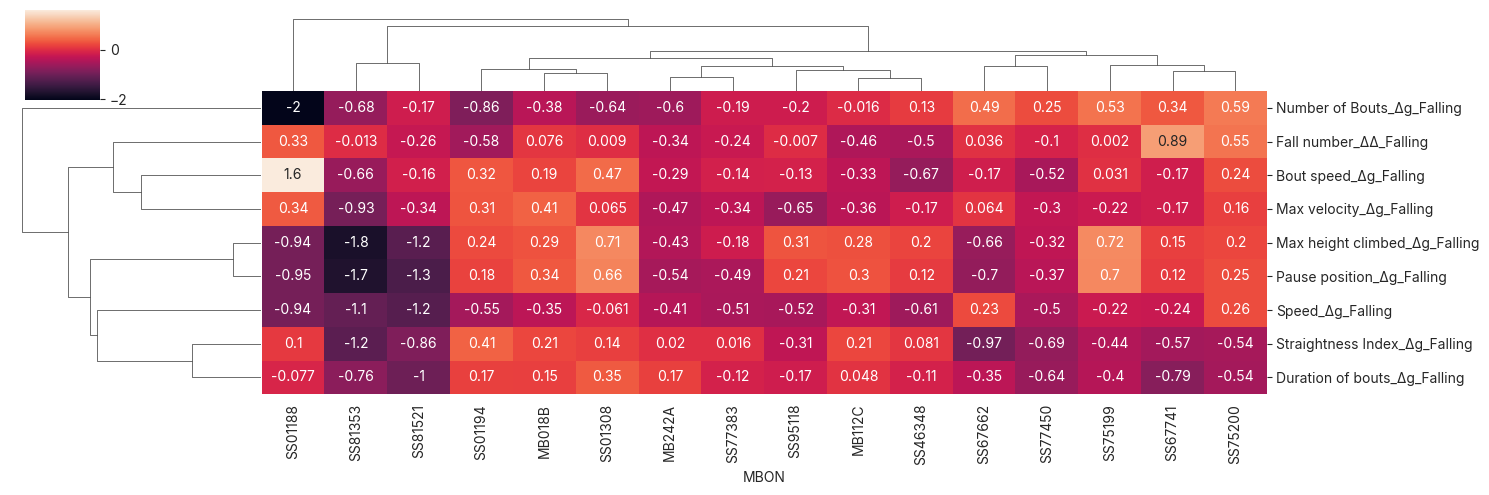

In [83]:
df_transpose = df_fallingcol.set_index('MBON').transpose()

df_heatmapcluster = sns.clustermap(df_transpose, annot=True, figsize=(15,5))
#plt.setp(df_heatmapcluster.ax_heatmap.get_xticklabels(), va='center', rotation=0, fontsize=8)

## Heatmap showing vertical vs horizontal diff

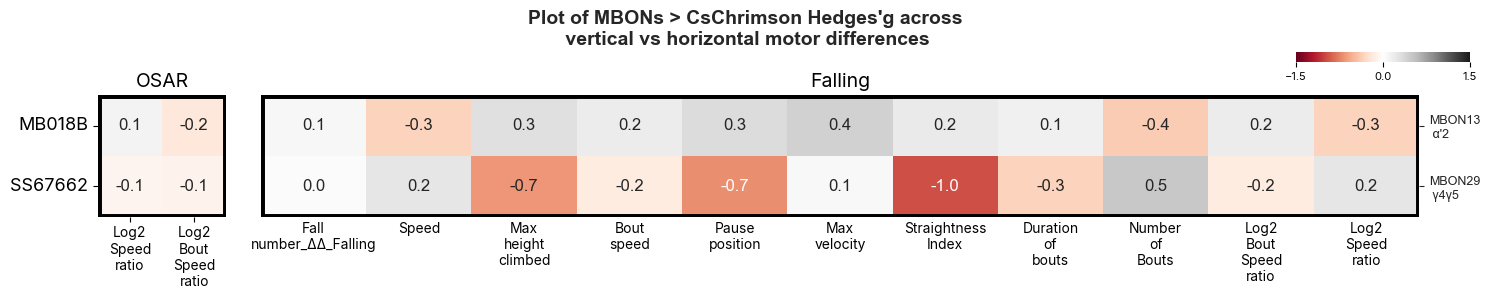

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "Chrimson2"
mbons_of_interest = ["MB018B", "SS67662"]

plt.rcParams["font.family"] = "Inter"


# Read the specific condition file
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

osarmatchdf = totalmetriccomparison.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].reset_index(drop=True)
    colormap = 'BrBG'

df_totalmetrics_origin = df_specificmbon[df_specificmbon['MBON'].isin(mbons_of_interest)]
df_totalmetrics = df_totalmetrics_origin.set_index(['MBON'])
df00 = df_specificmbon.set_index(['genotypeandresponder'])

#adding extra axes label
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = df_totalmetrics.copy()

for n in df_totalmetrics_origin['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

# Sort by MBON numbers instead of bspeed_deltag
df_singleresponder_lobeloc = df_singleresponder_lobeloc.sort_values(by = "Name", ascending=True)

# Separate data for two subplots
# Subplot 1: Only fallnumber (Delta-delta)
df60_fallnumber = df_singleresponder_lobeloc[['Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']].copy()

# Subplot 2: All other columns (Delta-g) 
df60_other = df_singleresponder_lobeloc.drop(['Name', 'Lobe', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR','PI_Δg_OSAR', 'genotypeandresponder', 'responder',
       'Light Attraction Index_Δg_OSAR'], axis = 1).copy() 

# Create figure with 2 subplots
fig1, (ax4_left, ax4_right) = plt.subplots(1, 2, figsize=(15, 3), gridspec_kw={'width_ratios': [1, 9]})

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Labels for subplot 1 (fallnumber)
xticklabel_fallnumber = ['Log2 Speed ratio', 'Log2 Bout Speed ratio']

# Labels for subplot 2 (other columns)
# xticklabellist_other = df60_other.columns.tolist()
xticklabellist_other = [a.replace("_Δg_Falling", " ") for a in df60_other.columns.tolist()]

#colorbar for subplot 2
cax2 = inset_axes(ax4_right,
                 width="15%",  # width: 40% of parent_bbox width
                 height="8%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.02, 1.5, 1, 1),
                 bbox_transform=ax4_right.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    

# Subplot 1: fallnumber (Delta-delta) - now with MBON names as y-labels       
j7_left = sns.heatmap(df60_fallnumber, ax = ax4_left, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, annot_kws={"size": 12, }, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabel_fallnumber, yticklabels=True,
                 clip_on=False, cbar = False)

# Subplot 2: other columns (Delta-g) - no y-labels on left side
j7_right = sns.heatmap(df60_other, ax = ax4_right, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist_other, yticklabels=True,
                 clip_on=False, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 12, })

# colorbar changes
cbar = j7_right.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# For more detailed control (optional):
for label in cbar.ax.get_xticklabels():  # Note: use get_xticklabels() for horizontal colorbar
    # label.set_fontsize(10)
    label.set_family('Inter')

    
# Format subplot 1
j7_left.set_ylabel('')
j7_left.set_yticklabels(j7_left.get_yticklabels(), va='center', rotation = 0, fontsize = 13)
j7_left.set_xticklabels(j7_left.get_xticklabels(),  rotation = 0,fontsize = 10)
j7_left.set_title('OSAR', fontsize = 14)
wrap_labels(j7_left, 2)

# Format subplot 2
j7_right.set_ylabel('')
j7_right.set_yticklabels([], visible = False)
j7_right.set_xticklabels(j7_right.get_xticklabels(), fontsize = 10)
wrap_labels(j7_right, 2)
j7_right.set_title('Falling',fontsize = 14)
j7_right.tick_params(axis='both', which='both', length=0)

# Drawing the frame for subplot 1
j7_left.axhline(y = 0, color = 'k', linewidth = 5) 
j7_left.axhline(y = len(df60_fallnumber), color = 'k', linewidth = 5) 
j7_left.axvline(x = 0, color = 'k', linewidth = 5) 
j7_left.axvline(x = 2, color = 'k', linewidth = 5) 

# Drawing the frame for subplot 2
j7_right.axhline(y = 0, color = 'k', linewidth = 5) 
j7_right.axhline(y = len(df60_other), color = 'k', linewidth = 5) 
j7_right.axvline(x = 0, color = 'k', linewidth = 5) 
j7_right.axvline(x = len(df60_other.columns), color = 'k', linewidth = 5) 

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = j7_right.twinx()
j8_right.set_ylim([0,j7_right.get_ylim()[0]])
j8_right.set_yticks(j7_right.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

fig1.suptitle(f"Plot of MBONs > {responderrename} Hedges'g across\n vertical vs horizontal motor differences", 
                x=0.5, weight='bold', fontsize=14)

fig1.tight_layout()

plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_horizontal vs vertical.png", dpi=1200)
#plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_horizontal vs vertical.svg")

plt.show()


## Heatmap of all light intensities

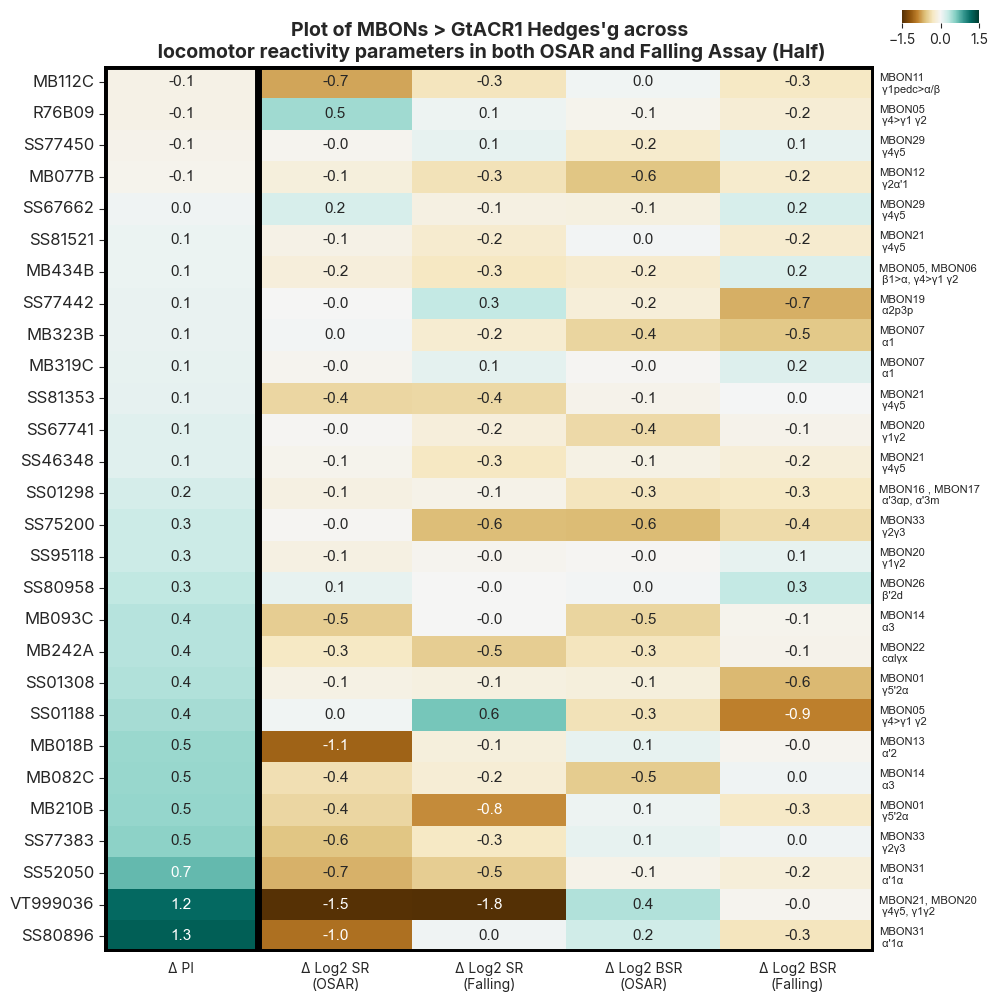

Generated heatmap for Half condition


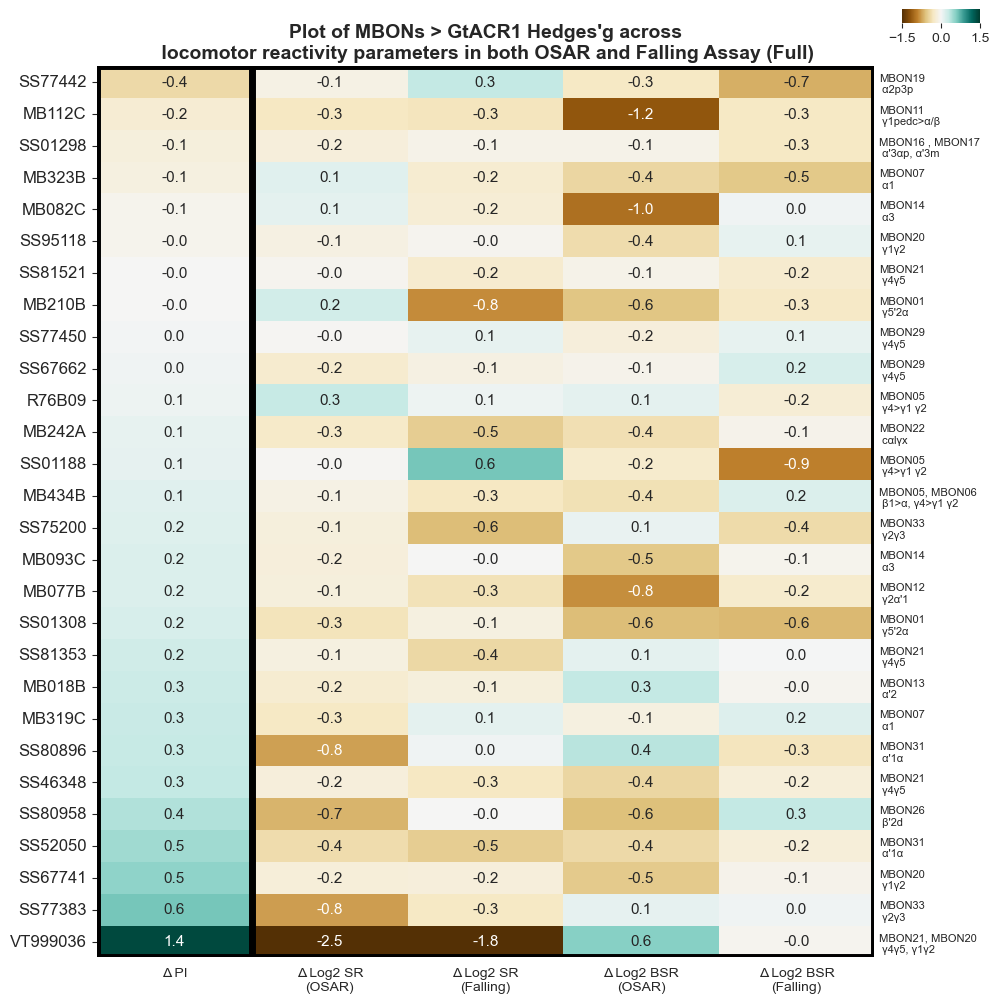

Generated heatmap for Full condition


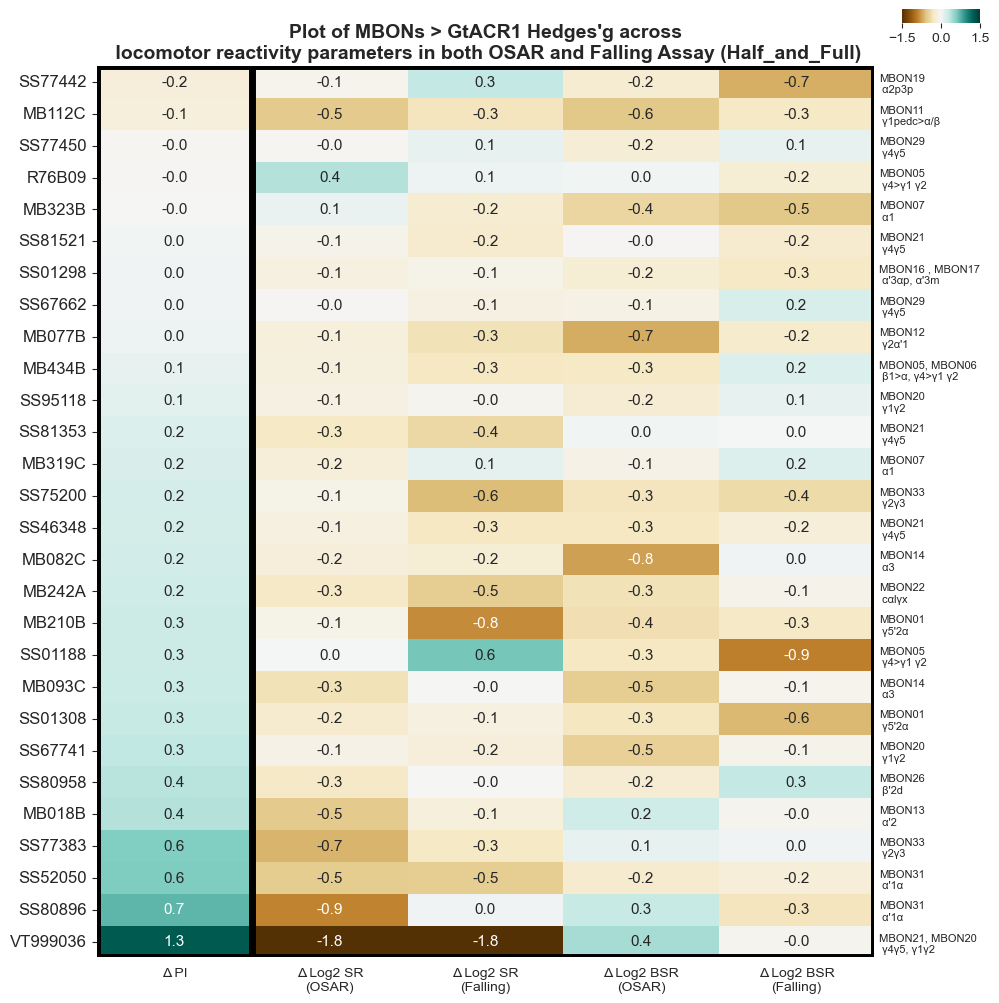

Generated heatmap for Half_and_Full condition


In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "ACR"

plt.rcParams["font.family"] = "Inter"

# Define the three condition files
conditions = ['Half', 'Full', 'Half_and_Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    osarmatchdf = totalmetriccomparison.copy()
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colormap = 'RdGy'
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colormap = 'BrBG'
    
    df00 = df_specificmbon.set_index(['genotypeandresponder'])
    
    fig1, ax3 = plt.subplots(figsize=(10,10))     
    
    # Adding extra axes label
    lobloclst = []
    mbonloclst = []
    df500 = df00.copy()
    for n in df00['MBON']:    
        lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df500['Lobe'] = lobloclst
    df500['Name'] = mbonloclst
    
    df00 = df00.drop(['MBON', 'responder'], axis=1)
    
    # Single responder labeling
    newdf500 = pd.DataFrame()
    naming = df500['Name'].to_frame().rename(columns={"Name": ""})
    lobing = df500['Lobe'].to_frame().rename(columns={"Lobe": ""})
    newlabel = (naming.values + "\n " + lobing.values).tolist()
    newdf500['Merge'] = newlabel
    
    # New labels for heatmap
    df00 = df00[['PI_Δg_OSAR', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Speed ratio_Δg_Falling', 
                 'Log2 Bout Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_Falling']]
    xticklabeldf = df00.rename(columns={
        'PI_Δg_OSAR': 'Δ PI',
        'Log2 Speed ratio_Δg_OSAR': "Δ Log2 SR (OSAR)",
        'Log2 Bout Speed ratio_Δg_OSAR': "Δ Log2 BSR (OSAR)",
        'Log2 Bout Speed ratio_Δg_Falling': 'Δ Log2 BSR (Falling)',
        'Log2 Speed ratio_Δg_Falling': 'Δ Log2 SR (Falling)'
    })
    xticklabellist = xticklabeldf.columns.tolist()
    yticklabels = [label.split("_")[0] for label in df00.index]
    
    # Colorbar
    cax = inset_axes(ax3,
                     width="10%",
                     height="1.5%",
                     loc='lower right',
                     bbox_to_anchor=(0.1, 1.08, 1, 1),
                     bbox_transform=ax3.transAxes,
                     borderpad=-2,
                     )
    
    sns.set_style("whitegrid", {'axes.grid': False})           
    j7 = sns.heatmap(df00, ax=ax3, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                     linewidths=0.0, edgecolor="none", xticklabels=xticklabellist, yticklabels=yticklabels,
                     clip_on=False, cbar_ax=cax, cbar_kws=dict(orientation="horizontal", ticks=[-1.5, 0, 1.5]), 
                     annot_kws={"size": 11})
    j7.set_ylabel('')
    j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation=0, fontsize=12)
    j7.set_xticklabels(j7.get_xticklabels(), rotation=0, fontsize=10)
    wrap_labels(j7, 10)
    
    # Drawing the frame
    j7.axhline(y=0, color='k', linewidth=5) 
    j7.axhline(y=len(df00), color='k', linewidth=5) 
    j7.axvline(x=0, color='k', linewidth=5) 
    j7.axvline(x=1, color='k', linewidth=5) 
    j7.axvline(x=len(df00.columns), color='k', linewidth=5) 
    
    # Secondary axes
    j8 = j7.twinx()
    j8.set_ylim([0, j7.get_ylim()[0]])
    j8.set_yticks(j7.get_yticks())
    j8.tick_params(length=0)
    
    # Y labels for mbon lobes and naming
    labellinglist = newdf500['Merge'].iloc[::-1]
    labelledlist = []
    for n in labellinglist:
        labelledlist.extend(n)
        
    j8.set_yticklabels(labelledlist, fontsize=8)
    j8.spines['top'].set_visible(False)
    j8.spines['right'].set_visible(False)
    j8.spines['bottom'].set_visible(False)
    j8.spines['left'].set_visible(False)
    
    j7.set_title(f"Plot of MBONs > {responderrename} Hedges'g across\n locomotor reactivity parameters in both OSAR and Falling Assay ({condition})", 
                 x=0.5, weight='bold', fontsize=14)
    
    fig1.tight_layout()
    
    plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_" + condition + ".png", dpi=1200)
    plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated heatmap for {condition} condition")

## Heatmap comparing all PIs of OSAR conditions

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "Chrimson2"

plt.rcParams["font.family"] = "Inter"

# Define the three condition files
conditions = ['Eighth','Quarter','Half', 'Full']

lightintensitycheck = pd.DataFrame()

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR and Falling_delta Log2SR and delta Log2BSR comparison-" + condition + ".xlsx")
    
    # Extract only MBON, genotypeandresponder, and Δ PI_OSAR columns
    temp_df = totalmetriccomparison[['MBON', 'genotypeandresponder', 'Δ PI_OSAR', 'Responder']].copy()
    
    # Rename the Δ PI_OSAR column to include the condition name
    temp_df = temp_df.rename(columns={'Δ PI_OSAR': f'Δ PI_OSAR-{condition}'})
    
    # Merge with the main dataframe
    if lightintensitycheck.empty:
        lightintensitycheck = temp_df
    else:
        lightintensitycheck = lightintensitycheck.merge(temp_df, on=['MBON', 'genotypeandresponder', 'Responder'], how='outer')


<Axes: ylabel='genotypeandresponder'>

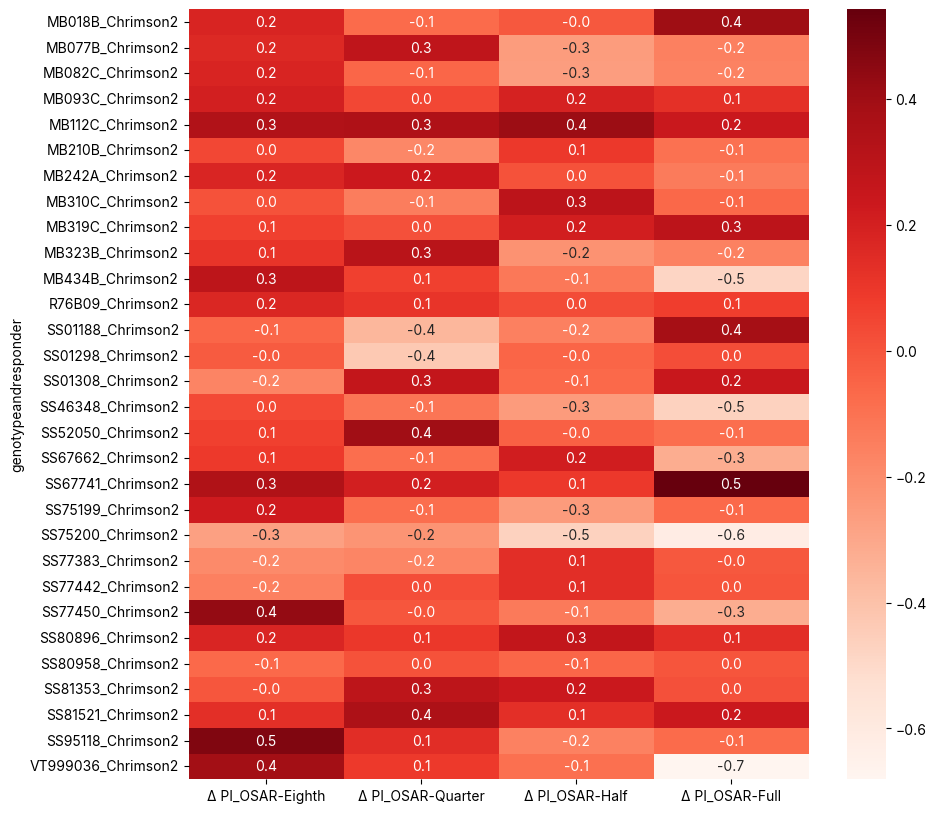

In [8]:
responder = "Chrimson2"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_lightint = lightintensitycheck[lightintensitycheck['Responder']=="Chrimson2"]
    colormap = "Reds"


if responder == 'ACR':
    responderrename = "GtACR1"
    df_lightint = lightintensitycheck[lightintensitycheck['Responder']=="ACR"]
    colormap = "Greens"


totalpiheatmap = df_lightint.drop(columns=['Responder', 'MBON']).set_index('genotypeandresponder')
fig_heatmappi, ax_heatmappi = plt.subplots(figsize=(10,10))   
 
sns.heatmap(totalpiheatmap, ax=ax_heatmappi, annot=True, fmt=".1f", cmap = colormap)

## Valence signs reversal

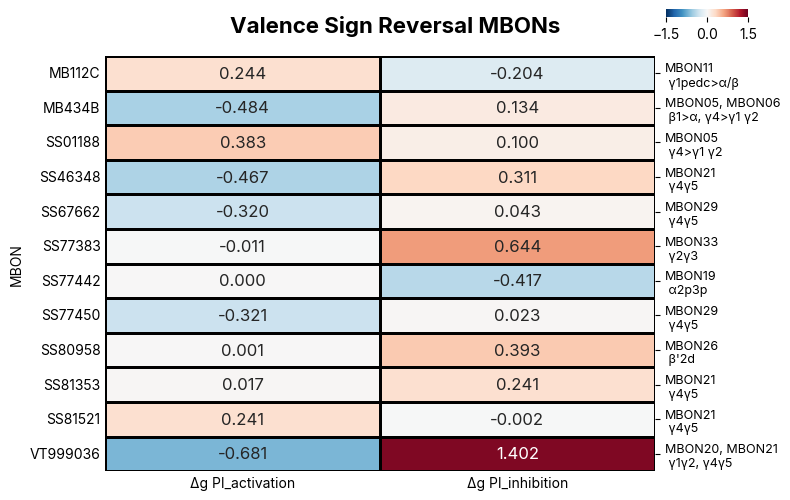

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Read the Excel files
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")
osar_chrimson = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
osar_acr = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)

# Extract PI values from both files
activation_pi = osar_chrimson[['MBON', 'PI_Δg_OSAR']].copy()
activation_pi['MBON'] = activation_pi['MBON'].astype(str)
activation_pi = activation_pi.rename(columns={'PI_Δg_OSAR': 'Δg PI_activation'})

inhibition_pi = osar_acr[['MBON', 'PI_Δg_OSAR']].copy()
inhibition_pi['MBON'] = inhibition_pi['MBON'].astype(str)
inhibition_pi = inhibition_pi.rename(columns={'PI_Δg_OSAR': 'Δg PI_inhibition'})

# Create DataFrame for heatmap
heatmapallmbons = activation_pi.merge(inhibition_pi, how="inner", on= "MBON")
mbons_of_interest = ['MB077B', "SS77442", "MB310C"]
heatmap_data = heatmapallmbons[heatmapallmbons['MBON'].isin(mbons_of_interest)].set_index("MBON")


#creating tags for mbon loctions and names
lobloclst = []
mbonloclst = []
df_singleresponder_lobeloc = heatmapallmbons[heatmapallmbons['MBON'].isin(mbons_of_interest)].copy()

for n in df_singleresponder_lobeloc['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_singleresponder_lobeloc['Lobe'] = lobloclst
df_singleresponder_lobeloc['Name'] = mbonloclst

newdf_singleresponder_lobeloc = pd.DataFrame()
naming = df_singleresponder_lobeloc['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_singleresponder_lobeloc['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf_singleresponder_lobeloc['Merge'] = newlabel

# Create figure and axis
fig_valence, ax_valence = plt.subplots(figsize=(8, 5))

#colorbar for subplot 2
cax2 = inset_axes(ax_valence,
                 width="15%",  # width: 40% of parent_bbox width
                 height="2%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.12, 1.16, 1, 1),
                 bbox_transform=ax_valence.transAxes,
                 borderpad=-2,
                 )
# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0, cbar_ax=cax2, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]),
            linewidths=2, linecolor='black', ax=ax_valence,
            vmin=-1.5, vmax=1.5,
            annot_kws={'size': 12})

ax_valence.set_xticklabels(ax_valence.get_xticklabels(), fontsize = 10)
ax_valence.tick_params(axis='both', which='both', length=0)

#secondary axes for subplot 2 - MBON lobe and naming labels on right side
j8_right = ax_valence.twinx()
j8_right.set_ylim([0,ax_valence.get_ylim()[0]])
j8_right.set_yticks(ax_valence.get_yticks())

#y labels for mbon lobes and naming on subplot 2 (right side)
labellinglist = newdf_singleresponder_lobeloc['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
j8_right.set_yticklabels(labelledlist, fontsize=9)
j8_right.spines['top'].set_visible(False)
j8_right.spines['right'].set_visible(False)
j8_right.spines['bottom'].set_visible(False)
j8_right.spines['left'].set_visible(False)

# Customize plot
fig_valence.suptitle('Valence Sign Reversal MBONs', fontsize=16, fontweight='bold')

# Tight layout
fig_valence.tight_layout()

# Save figure
# plt.savefig(filesavedir + date + "_valencesigreveralmbons.png", dpi = 1200, bbox_inches='tight')

# Show plot



